In [1]:
import pandas as pd

In [2]:
swiss_prot_plants_sm = pd.read_csv("../data/swiss_prot_ec_plants_sm.csv")

In [3]:
from ec_number_prediction.data_processing_pipeline.multi_label_binarizer import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
final_dataset = mlb.divide_labels_by_EC_level("../data/swiss_prot_ec_plants_sm.csv")
final_dataset = mlb.get_final_labels(final_dataset)

EC1 is not null


In [4]:
final_dataset

,accession,name,sequence,EC,lineage,species,taxonomy_id,EC1,EC2,EC3,...,5.5.1.6,5.5.1.8,6.2.1.1,6.2.1.12,6.2.1.17,6.2.1.2,6.2.1.25,6.2.1.27,6.2.1.34,6.3.4.5
0,Q7XQ85,1A12_ORYSJ,MAYQGIDLLSTKAAGDDHGENSSYFDGWKAYDTNPFDLRHNRGGVI...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,P18485,1A12_SOLLC,MGFEIAKTNSILSKLATNEEHGENSPYFDGWKAYDSDPFHPLKNPN...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A0A0P0WIY3,1A13_ORYSJ,MVGRMLSSPEPTLSTMAMSAAHGEDSPYFAGWRAYDEDPYDPITNP...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Q42881,1A13_SOLLC,MKLLSEKATCNSHGQDSSYFLGWQEYEKNPYDEIQNPKGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Q43309,1A14_ARATH,MVQLSRKATCNSHGQVSSYFLGWEEYEKNPYDVTKNPQGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1620,G3FIN9,UGTK5_MANES,MGSLASEIPPHAVLVPYPAQGHVNPLMQLGKLLHSRGFYITFVNTE...,2.4.1.63,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Manihot esculenta,3983,2,2.4,2.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1621,Q39978,VTSS1_HYOMU,MAPAIVMSNYEEEEIVRPVADFSPSLWGDHFHSFSVDNQVAEKYAQ...,4.2.3.21,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Hyoscyamus muticus,35626,4,4.2,4.2.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1622,Q9XJ32,VTSS1_SOLTU,MTPAAVVMSNYGEEEIVRPIADFSPSLWGDRFHSFSLDNQIAGKYA...,4.2.3.21,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum tuberosum,4113,4,4.2,4.2.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1623,Q39979,VTSS2_HYOMU,SRWWKDLDFVTTLPYARDRAVECYFWTMGVYAEPQYSQARVMLAKT...,4.2.3.21,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Hyoscyamus muticus,35626,4,4.2,4.2.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
import re

def get_ec_levels(labels):
    level_1 = []
    level_2 = []
    level_3 = []
    level_4 = []
    for i, label in enumerate(labels):
        if re.match(r"^\d+.\d+.\d+.n*\d+$", label):
            level_4.append(i)
        elif re.match(r"^\d+.\d+.\d+$", label):
            level_3.append(i)
        elif re.match(r"^\d+.\d+$", label):
            level_2.append(i)
        elif re.match(r"^\d+$", label):
            level_1.append(i)
    return level_1, level_2, level_3, level_4

level_1, level_2, level_3, level_4 = get_ec_levels(final_dataset.columns[11:])

In [6]:
y_true_ = final_dataset.iloc[:, 11:]
y_true_ = y_true_.to_numpy()

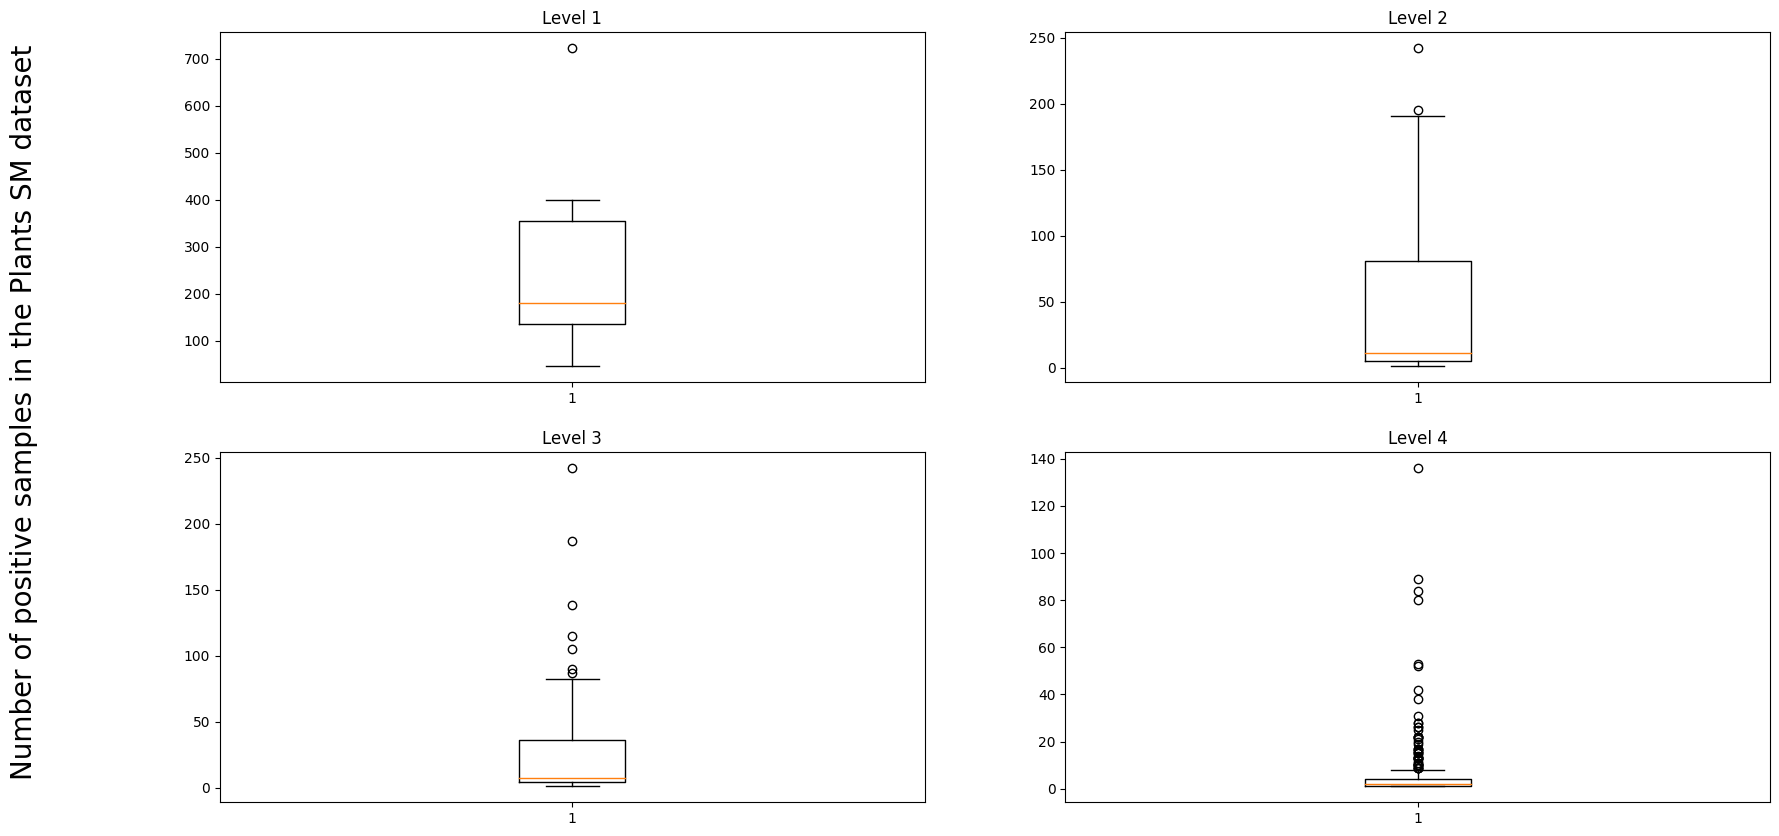

In [7]:
# get distribution of labels for level 4
import numpy as np

# remove all 0 values and create boxplot for level 4
y_true_level_4 = y_true_[:, level_4]
y_true_level_4 = y_true_level_4[y_true_level_4.sum(axis=1) != 0]
distribution_level4 = y_true_level_4.sum(axis=0)

y_true_level_3 = y_true_[:, level_3]
y_true_level_3 = y_true_level_3[y_true_level_3.sum(axis=1) != 0]
distribution_level3 = y_true_level_3.sum(axis=0)

y_true_level_2 = y_true_[:, level_2]
y_true_level_2 = y_true_level_2[y_true_level_2.sum(axis=1) != 0]
distribution_level2 = y_true_level_2.sum(axis=0)

y_true_level_1 = y_true_[:, level_1]
y_true_level_1 = y_true_level_1[y_true_level_1.sum(axis=1) != 0]
distribution_level1 = y_true_level_1.sum(axis=0)

# make 4 plots instead of only one
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
plt.boxplot(distribution_level1)
fig.supylabel('Number of positive samples in the Plants SM dataset', fontsize=20)
# plt.ylabel('Number of positive samples in the evidence-level dataset')
plt.title('Level 1')
plt.subplot(2, 2, 2)
plt.boxplot(distribution_level2)
plt.title('Level 2')
plt.subplot(2, 2, 3)
plt.boxplot(distribution_level3)
plt.title('Level 3')
plt.subplot(2, 2, 4)
plt.boxplot(distribution_level4)
plt.title('Level 4')
plt.show()


In [8]:
pd.DataFrame(distribution_level2).describe()

,0
count,34.000000
mean,48.764706
std,64.438394
min,1.000000
25%,5.000000
50%,11.000000
75%,80.500000
max,242.000000


In [9]:
pd.DataFrame(distribution_level3).describe()

,0
count,53.000000
mean,31.471698
std,49.680364
min,1.000000
25%,4.000000
50%,7.000000
75%,36.000000
max,242.000000


In [10]:
pd.DataFrame(distribution_level4).describe()

,0
count,361.00000
mean,5.33795
std,12.11046
min,1.00000
25%,1.00000
50%,2.00000
75%,4.00000
max,136.00000


In [11]:
# drop from dataset all labels that have less than 5 samples
final_dataset_ = final_dataset.iloc[:, 11:]
final_dataset_ = final_dataset_.loc[:, final_dataset_.sum(axis=0) >= 4]
final_dataset_

,1,2,3,4,5,6,1.1,1.13,1.14,1.17,...,4.4.1.14,5.2.1.13,5.3.3.2,5.5.1.12,5.5.1.13,5.5.1.19,5.5.1.4,5.5.1.6,6.2.1.12,6.2.1.34
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1620,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1621,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1622,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1623,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
final_dataset = pd.concat([final_dataset.iloc[:, :11], final_dataset_], axis=1)
final_dataset

,accession,name,sequence,EC,lineage,species,taxonomy_id,EC1,EC2,EC3,...,4.4.1.14,5.2.1.13,5.3.3.2,5.5.1.12,5.5.1.13,5.5.1.19,5.5.1.4,5.5.1.6,6.2.1.12,6.2.1.34
0,Q7XQ85,1A12_ORYSJ,MAYQGIDLLSTKAAGDDHGENSSYFDGWKAYDTNPFDLRHNRGGVI...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,4,4.4,4.4.1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,P18485,1A12_SOLLC,MGFEIAKTNSILSKLATNEEHGENSPYFDGWKAYDSDPFHPLKNPN...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,4,4.4,4.4.1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A0A0P0WIY3,1A13_ORYSJ,MVGRMLSSPEPTLSTMAMSAAHGEDSPYFAGWRAYDEDPYDPITNP...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,4,4.4,4.4.1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Q42881,1A13_SOLLC,MKLLSEKATCNSHGQDSSYFLGWQEYEKNPYDEIQNPKGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,4,4.4,4.4.1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Q43309,1A14_ARATH,MVQLSRKATCNSHGQVSSYFLGWEEYEKNPYDVTKNPQGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,4,4.4,4.4.1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1620,G3FIN9,UGTK5_MANES,MGSLASEIPPHAVLVPYPAQGHVNPLMQLGKLLHSRGFYITFVNTE...,2.4.1.63,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Manihot esculenta,3983,2,2.4,2.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1621,Q39978,VTSS1_HYOMU,MAPAIVMSNYEEEEIVRPVADFSPSLWGDHFHSFSVDNQVAEKYAQ...,4.2.3.21,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Hyoscyamus muticus,35626,4,4.2,4.2.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1622,Q9XJ32,VTSS1_SOLTU,MTPAAVVMSNYGEEEIVRPIADFSPSLWGDRFHSFSLDNQIAGKYA...,4.2.3.21,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum tuberosum,4113,4,4.2,4.2.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1623,Q39979,VTSS2_HYOMU,SRWWKDLDFVTTLPYARDRAVECYFWTMGVYAEPQYSQARVMLAKT...,4.2.3.21,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Hyoscyamus muticus,35626,4,4.2,4.2.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
X = final_dataset.iloc[:, 0:11]
y = final_dataset.iloc[:, 11:]

In [14]:
import os
from skmultilearn.model_selection import IterativeStratification
from ec_number_prediction.data_processing_pipeline.split import StratifiedSplit

stratifier = IterativeStratification(n_splits=5, order=2)

i=0
for fold in stratifier.split(X, y):
    train_indexes, test_indexes = fold
    print(f"Fold {i}")
    X_train = X.iloc[train_indexes]
    y_train = y.iloc[train_indexes, :]

    X_test = X.iloc[test_indexes]
    y_test = y.iloc[test_indexes, :]

    splitter = StratifiedSplit()
    df_with_stats, table_styled = splitter.generate_stats(y_train, y_test)

    X_train, y_train, x_test, y_test = splitter.correct_split(X_train, y_train, X_test, y_test, df_with_stats, validation = False, compensation=2)

    train_dataset = pd.concat([X_train, y_train], axis=1)
    test_dataset = pd.concat([x_test, y_test], axis=1)

    train_dataset = train_dataset.sample(frac=1)
    test_dataset = test_dataset.sample(frac=1)

    if not os.path.exists("../data/plants_sm/train_datasets"):
        os.makedirs("../data/plants_sm/train_datasets")
    if not os.path.exists("../data/plants_sm/test_datasets"):
        os.makedirs("../data/plants_sm/test_datasets")
    train_dataset.to_csv(f"../data/plants_sm/train_datasets/train_dataset_{i}.csv", index=False)
    test_dataset.to_csv(f"../data/plants_sm/test_datasets/test_dataset_{i}.csv", index=False)
    df_with_stats, table_styled = splitter.generate_stats(y_train, y_test)
    table_styled.to_html(f"../data/plants_sm/dataset_{i}_stats.html")
    i+=1

Fold 0
Fold 1
Fold 2
Fold 3
Fold 4


In [2]:
import pandas as pd

train_dataset = pd.read_csv(f"../data/plants_sm/test_datasets/test_dataset_0.csv")

train_dataset


,accession,name,sequence,EC,lineage,species,taxonomy_id,EC1,EC2,EC3,...,4.4.1.14,5.2.1.13,5.3.3.2,5.5.1.12,5.5.1.13,5.5.1.19,5.5.1.4,5.5.1.6,6.2.1.12,6.2.1.34
0,Q9LMM1,C86A4_ARATH,MEISNAMLLVAIVTGYWLWFKRISRWLKGPRVWPLLGSLPGLIEQR...,1.14.14.1,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,1,1.14,1.14.14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,O65378,ACCO3_ARATH,MEMNIKFPVIDLSKLNGEERDQTMALIDDACQNWGFFELVNHGLPY...,1.14.17.4,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,1,1.14,1.14.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Q53RB0,LOX4_ORYSJ,MQVQGFFDRLTGRNKEAWKEGRIRGTAVLVKKDVLGLGDFHASLLD...,1.13.11.58,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,1,1.13,1.13.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Q94IP1,TCMO_SORBI,MDLVLLEKALLGLFAAAVLAVAVAKLTGKRYRLPPGPAGAPVVGNW...,1.14.14.91,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Sorghum bicolor,4558,1,1.14,1.14.14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Q0WPW4,ACCO5_ARATH,MAIPVIDFSKLNGEEREKTLSEIARACEEWGFFQLVNHGIPLELLN...,1.14.17.4,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,1,1.14,1.14.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,M4HYP3,MISO1_PINCO,MAMPSYSSLSSHISITTTHTRPHPIFPCYNDTQSIPRFFISSDTGS...,4.2.3.44,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Pinus contorta,3339,4,4.2,4.2.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
331,P80042,GGPPS_CAPAN,MRSMNLVDLWAQQACLVFNQTLSYKSFNGFMKIPLKNSKINPKLNK...,2.5.1.1;2.5.1.10;2.5.1.29;2.5.1.-,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Capsicum annuum,4072,2,2.5,2.5.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
332,P51107,DFRA_SOLLC,MASEAHAVVDAHSPPKTTTVWVTGGAGFIGSWLVMRLLERGYNVHA...,1.1.1.219;1.1.1.234,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,1,1.1,1.1.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
333,P46420,GSTF4_MAIZE,MATPAVKVYGWAISPFVSRALLALEEAGVDYELVPMSRQDGDHRRP...,2.5.1.18,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Zea mays,4577,2,2.5,2.5.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1]:
import pandas as pd

plants_dataset = pd.read_csv("../data/swiss_prot_ec_plants.csv")
plants_dataset

,accession,name,sequence,EC,lineage,species,taxonomy_id
0,Q7XQ85,1A12_ORYSJ,MAYQGIDLLSTKAAGDDHGENSSYFDGWKAYDTNPFDLRHNRGGVI...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947
1,P18485,1A12_SOLLC,MGFEIAKTNSILSKLATNEEHGENSPYFDGWKAYDSDPFHPLKNPN...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081
2,A0A0P0WIY3,1A13_ORYSJ,MVGRMLSSPEPTLSTMAMSAAHGEDSPYFAGWRAYDEDPYDPITNP...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947
3,Q42881,1A13_SOLLC,MKLLSEKATCNSHGQDSSYFLGWQEYEKNPYDEIQNPKGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081
4,Q43309,1A14_ARATH,MVQLSRKATCNSHGQVSSYFLGWEEYEKNPYDVTKNPQGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702
...,...,...,...,...,...,...,...
15514,Q9FLM3,ZDH23_ARATH,MYVVTPPQRSGFGSDCDLRVYQTWKGSNIFCLQGRFIFGPDVRSLG...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702
15515,Q8VYS8,ZDH24_ARATH,MAGRVFEAWKGSNKFLFGGRLIFGPDAWSIPFTFLLIITPVCFFSV...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702
15516,Q9C533,ZDHC1_ARATH,MRKHGWQLPYHPLQVVAVAVFLALGFAFYVFFAPFVGKKIHQYIAM...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702
15517,Q3EC11,ZDHC2_ARATH,MDSSEIEVVPLDSNSHQSPTESPTITDVFSASAYGDLHQLKHFVEH...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702


In [17]:
import os
from ec_number_prediction.data_processing_pipeline.multi_label_binarizer import MultiLabelBinarizer

for i in range(5):
    test_dataset = pd.read_csv(f"../data/plants_sm/test_datasets/test_dataset_{i}.csv")
    accessions = test_dataset["accession"]
    train_dataset = plants_dataset[~plants_dataset["accession"].isin(accessions)]
    os.makedirs("../data/plants_sm/train_dataset_all_data_plants/", exist_ok=True)
    train_dataset.to_csv(f"../data/plants_sm/train_dataset_all_data_plants/train_dataset_{i}.csv", index=False)

    mlb = MultiLabelBinarizer()
    final_dataset = mlb.divide_labels_by_EC_level(f"../data/plants_sm/train_dataset_all_data_plants/train_dataset_{i}.csv")
    final_dataset = mlb.get_final_labels(final_dataset)
    final_dataset = pd.concat([final_dataset.iloc[:, :11], final_dataset.loc[:, test_dataset.columns[11:]]], axis=1)
    final_dataset.to_csv(f"../data/plants_sm/train_dataset_all_data_plants/train_dataset_{i}.csv", index=False)
    
    print(f"Dataset {i} done")

EC1 is not null
Dataset 0 done
EC1 is not null
Dataset 1 done
EC1 is not null
Dataset 2 done
EC1 is not null
Dataset 3 done
EC1 is not null
Dataset 4 done


In [20]:
import numpy as np

train_dataset = pd.read_csv("../data/plants_sm/train_dataset_all_data_plants/train_dataset_1.csv")
test_dataset = pd.read_csv("../data/plants_sm/test_datasets/test_dataset_1.csv")
assert train_dataset["accession"].isin(test_dataset["accession"]).sum() == 0
assert np.array_equal(train_dataset.columns[11:], test_dataset.columns[11:])